# Fashion MNIST

In [44]:
import numpy as np
import torch
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
from IPython.display import display, Markdown, clear_output
import time
import matplotlib.pyplot as plt


### Dataset

In [27]:
(train_images, y_train), (test_images, y_test) = keras.datasets.fashion_mnist.load_data()

dataset_labels = [
    "T-shirt/top",  # index 0
    "Trouser",      # index 1
    "Pullover",     # index 2 
    "Dress",        # index 3 
    "Coat",         # index 4
    "Sandal",       # index 5
    "Shirt",        # index 6 
    "Sneaker",      # index 7 
    "Bag",          # index 8 
    "Ankle boot"    # index 9
]


Shirt


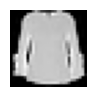

In [30]:
plt.rcParams['figure.figsize'] = (1,1)
index = 8888
plt.imshow(train_images[index], cmap='gray')
plt.axis('off')
print(dataset_labels[y_train[index]])

Reshape

In [34]:
x_train = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

### Model

In [38]:
from keras import layers

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

### Train

In [39]:
model.fit(x_train, y_train, 512, 20, )

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6624 - loss: 0.9442
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7804 - loss: 0.5899
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8115 - loss: 0.5179
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8317 - loss: 0.4709
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8466 - loss: 0.4299
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8573 - loss: 0.4014
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8651 - loss: 0.3778
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8712 - loss: 0.3617
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8766 - loss: 0.3459
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8794 - loss: 0.3353
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8853 - loss: 0.3214
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 

In [40]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8874 - loss: 0.3058


[0.3057903051376343, 0.8873999714851379]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


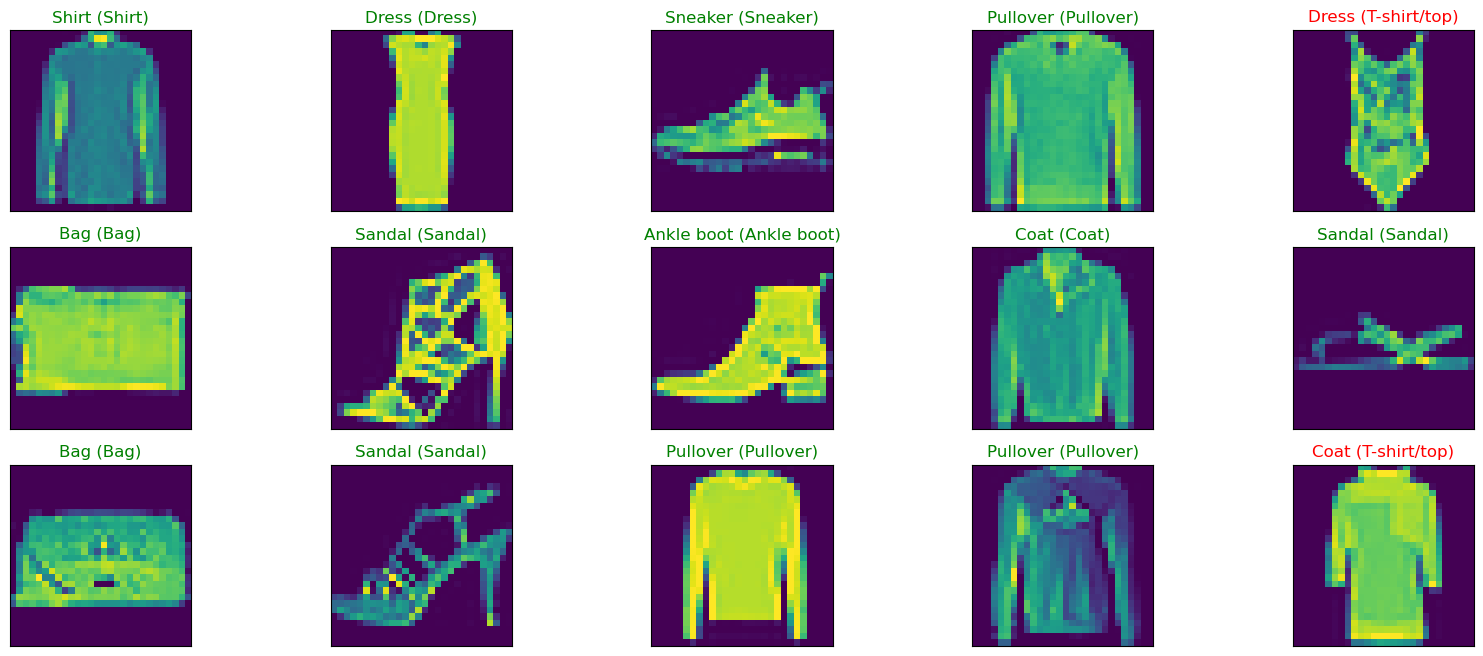

In [51]:
# Define the text labels
# Reference: https://colab.research.google.com/github/margaretmz/deep-learning/blob/master/fashion_mnist_keras.ipynb#scrollTo=oJv7XEk10bOv
# x_test: our test data
y_hat = model.predict(x_test)

# Plot a random sample of 10 test images, their predicted labels and ground truth
figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(x_test.shape[0], size=15, replace=False)):
    ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    # Display each image (x_test: our test data)
    ax.imshow(np.squeeze(x_test[index]))    
    predict_index = np.argmax(y_hat[index])
    # (y_test: our test labels)
    # true_index = np.argmax(y_test[index])
    true_index = y_test[index]
    # Set the title for each image
    ax.set_title("{} ({})".format(
        dataset_labels[predict_index],
        dataset_labels[true_index]),
        color=("green" if predict_index == true_index else "red")
    )